## FINN installation

Install Docker to run [without root](https://docs.docker.com/engine/install/linux-postinstall/#manage-docker-as-a-non-root-user)

`git clone https://github.com/Xilinx/finn/`

Set environment variables pointing to the Vivado location, for example:

`export FINN_XILINX_PATH=/home/patryk/Desktop/vivado`

`export FINN_XILINX_VERSION=2022.2`

**Make sure the path and the version is valid on your machine**

You have to run these commands in the terminal each time before running FINN, or you can put them in `~/.bashrc` file and run `source ~/.bashrc` command or restart the computer.

The Vivado will be used to generate network modules with High Level Synthesis, set up communication between programmable logic and the processing system, and generate final bitstream to be loaded on FGPA.

This notebook was prepared using FINN version v0.10.1, so checkout the repository to this version:

`cd finn`

`git checkout v0.10.1`

You can make sure that the variables are set up correctly by running:

`echo $FINN_XILINX_PATH`

`echo $FINN_XILINX_VERSION`

**With the FINN configured, put this notebook and model weights from previous exercise into `notebooks` directory in the FINN repository.**

Finally, run the FINN environment by running:

`./run-docker.sh notebook`

The first launch may take a while, and if everything is right you will see something like this:

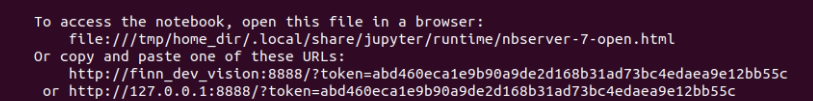

Now use either link with a web browser to open Jupyter notebook interface, where you can see the `notebooks` directory contents.

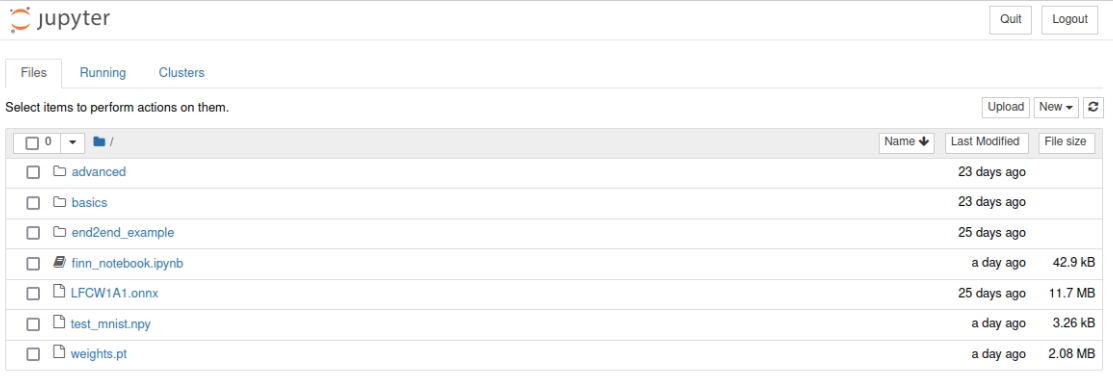

**Copy this notebook into finn/notebooks directory and from now on, use this notebook from there.**  

## 1. Model inspection and cleanup

First, let's visualize the computational graph of our model that we exported in the previous exercise.
We will be using `Netron` for visualizing graphs in `onnx` format, this view is interactive so we can inspect attributes of each node/connection.

In [1]:
from finn.util.visualization import showInNetron
# showInNetron("qalexnet_exported.onnx")

`Quant` nodes perform fake quantization operation (equation $(5)$ from previous exercise).
The ones connected to `Conv` nodes perform weight quantization and the pair of (`Relu`, `Quant`) nodes implement `brevitas.nn.QuantReLU` operation in our model and is used to requantize the activation that goes into the next layer (refer to pytorch description of our model from previous exercise).

This `Quant` node has four inputs:
- real-valued tensor to be quantized
- quantization scales (these can be independent for each channel)
- zero-point
- bit width

Now let's tidy_up our graph by inferring tensor shapes, datatypes and giving readable names to nodes and tensors.

🔔 **TODO (1)** Analyse the graph and compare it to architecture of the `QAlexNetV5` model from previous exercise.

🔔 **TODO (2)** Why do we need this activation requantization operation performed `Quant` nodes after `Relu` operation? Answer in the cell below (in one, two sentences)

#TODO 2
...
#TODO 2 end

In [2]:
from qonnx.core.modelwrapper import ModelWrapper
from qonnx.transformation.infer_shapes import InferShapes
from qonnx.transformation.fold_constants import FoldConstants
from qonnx.transformation.infer_datatypes import InferDataTypes
from qonnx.transformation.general import GiveReadableTensorNames, GiveUniqueNodeNames, RemoveStaticGraphInputs


def tidy_up(model):
    model = model.transform(InferShapes())
    model = model.transform(FoldConstants())
    model = model.transform(GiveUniqueNodeNames())
    model = model.transform(GiveReadableTensorNames())
    model = model.transform(InferDataTypes())
    model = model.transform(RemoveStaticGraphInputs())

    return model


model = ModelWrapper("qalexnet_exported.onnx")
model = tidy_up(model)
model.save("qalexnet_tidy_up.onnx")
#showInNetron("qalexnet_tidy_up.onnx")

## 2. Adding pre-processing

Notice that during training and validation of our model we transformed `uint8` input of shape $1\times1\times28\times28$ by using `ToTensor()` transform (look how we created `datasets.MNIST()` objects).

This operation scales input values into $[0, 1]$ range by dividing by $255$, we can perform this operation in our accelerator.
Also, we can set the datatype of the graph's input to `uint8`.

Analyse the code and notice the `Div` node at the beginning of the graph generated below:

In [3]:
import torch
from qonnx.core.datatype import DataType
from qonnx.util.cleanup import cleanup_model
from qonnx.transformation.merge_onnx_models import MergeONNXModels
from brevitas.export import export_qonnx
from finn.util.pytorch import ToTensor


# read graph and get name of the input
model = ModelWrapper("qalexnet_tidy_up.onnx")
global_inp_name = model.graph.input[0].name
ishape = model.get_tensor_shape(global_inp_name)

# create a mini-graph that performs ToTensor() operation
export_qonnx(ToTensor(), torch.randn(ishape), "preproc.onnx")
pre_model = ModelWrapper("preproc.onnx")

# merge graphs and set the datatype
model = model.transform(MergeONNXModels(pre_model))
model.set_tensor_datatype(global_inp_name, DataType["UINT8"])
model = tidy_up(model)
model.save("qalexnet_preproc.onnx")
# showInNetron("qalexnet_preproc.onnx")

/home/patryk/Desktop/MASTER_THIESIS/finn_SAS/finn/deps/qonnx/src/qonnx/transformation/merge_onnx_models.py:70: UserWarning: [MergeONNXModels] opsets for models to merge differ: 14 vs 17, output model will use opset 17
  warnings.warn(
/home/patryk/Desktop/MASTER_THIESIS/finn_SAS/finn/deps/qonnx/src/qonnx/transformation/infer_data_layouts.py:127: UserWarning: Assuming 4D input is NCHW
  warnings.warn("Assuming 4D input is NCHW")


KeyboardInterrupt: 

## 3. Hardware implementation of quantizers

Let's take a look at convolution operation for a single filter location (which in essence is just a dot product between input vector $\mathbf{\hat{x}}$ and weight vector $\mathbf{w'}$):

\begin{equation}
y = \mathbf{w'}^T \mathbf{\hat{x}} \tag{1}
\end{equation}

\begin{equation}
y = \sum_{i} {w'}_i \hat{x}_i \tag{2}
\end{equation}

Now let's assume that the input $\mathbf{\hat{x}}$ is already integer-valued and weights $\mathbf{w'}$ are scaled integers - dequantized representation of some integer vector $\mathbf{\hat{w}}$ with quantization scale $S_w$, so:

\begin{equation}
\mathbf{w'} = S_w \mathbf{\hat{w}}
\tag{3}
\end{equation}

Substituting $(3)$ into $(2)$ gives us:

$y = \sum_{i} S_w \hat{w}_i \hat{x}_i$

We can move $S_w$ in front of the sum and perform the convlution purely in integer domain:

$y = S_w \sum_{i} \hat{w}_i \hat{x}_i$

Described analysis done by the `FoldQuantWeights()` operation below:

In [ ]:
from finn.transformation.qonnx.fold_quant_weights import FoldQuantWeights
from qonnx.transformation.quant_constant_folding import FoldTransposeIntoQuantInit
from qonnx.transformation.extract_conv_bias import ExtractBiasFromConv

model = ModelWrapper("qalexnet_preproc.onnx")
# Extract bias from convolution as additional Add operation afterwards
model = model.transform(ExtractBiasFromConv())
# For the very last layer of our model, the weights are transposed before being fed into the MatMul node
#(look at the qalexnet_preproc.onnx graph), we can transpose the weights offline and skip this transpose operation in our graph
model = model.transform(FoldTransposeIntoQuantInit())
# Make sure the datatypes exist, these are required for folding the weights
model = model.transform(InferDataTypes())
# Fold weights
model = model.transform(FoldQuantWeights())

model.save("qalexnet_quants_converted.onnx")
# showInNetron("qalexnet_quants_converted.onnx")

Inspect the graph, notice how the values of the new `Mul` nodes are the same as quantization scales of the `Quant` node that was being folded.

Now we are left with activation requantization `Quant` nodes. Remember that this node implements the fake quantization operation:

$Quant(x) = dequantize(quantize(x))$

In FINN, the $quantize(x)$ part is implemented by the `MultiThreshold` operation $T(x, \mathbf{t})$:

\begin{equation}
  T(x, \mathbf{t}) =
    \begin{cases}
      0, & x \leq t_0\\
      1, & t_0 \leq x \leq t_1\\
      ... & ...\\
      n-1, & t_{n-2} \leq x \leq t_{n-1}\\
      n, & t_{n-1} < x
    \end{cases}
    \tag{4}
\end{equation}

In other words, instead of computing the quantized value by division and rounding operation (equation $(3)$ from the previous notebook), we precompute the quantization steps store them in the threshold vector $\mathbf{t}$ in equation $(4)$.

Since we are not using zero-points in this exercise, the $dequantize(x)$ function is simply multiplication by the quantization scale $S_x$, so:

\begin{equation}
Quant(x) = S_x T(x, \mathbf{t})
\tag{5}
\end{equation}

The `ConvertQuantActToMultiThreshold` transformation below substitutes every `Quant` node responsible for activation quantization by `MultiThreshold` and `Mul` nodes.

Analyse the generated graph.

In [ ]:
from finn.transformation.qonnx.quant_act_to_multithreshold import ConvertQuantActToMultiThreshold


model = ModelWrapper("qalexnet_quants_converted.onnx")
# Convert activations
model = model.transform(ConvertQuantActToMultiThreshold())

model = tidy_up(model)
model.save("qalexnet_quants_converted.onnx")
# showInNetron("qalexnet_quants_converted.onnx")

## 4. Streamlining

One of advantages coming from using `MultiThreshold` operation is that computing of an affine operations $ax + b$ (every `Mul` and `Add` node in the graph above is an affine operation) can be omitted and implicitly performed by the $T(x, \mathbf{t})$ function (equation $(4)$) by substituting $t_i \gets (t_i - b)/a$.

Also, because convolution of some scaled input $Ax$ is the same as scaling the convolution of unchanged input $x$:

$conv(Sx) = S conv(x)$

We can reorder `Mul` and `Conv` nodes.

🔔 **TODO (3)** Experiment and use transformations imported below to fill missing transformations in `streamling_transformations`. Inspect the `qalexnet_streamlined.onnx` graph, look what is the result of each transformation and decide which transformation should be called next. The final graph should look like this:

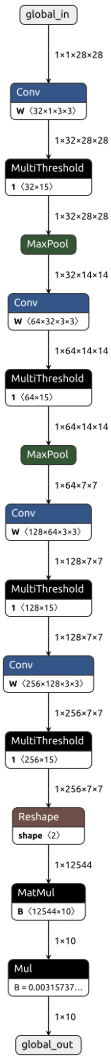

In [ ]:
from qonnx.transformation.general import ConvertDivToMul
from finn.transformation.streamline.reorder import (
    MoveScalarMulPastConv,
    MoveAddPastConv,
    MoveAddPastMul,
    MoveMulPastMaxPool,
    MoveScalarAddPastMatMul,
    MoveScalarMulPastMatMul,
    MoveScalarLinearPastInvariants,
)
from finn.transformation.streamline.collapse_repeated import CollapseRepeatedMul
from finn.transformation.streamline.absorb import (
    AbsorbAddIntoMultiThreshold,
    AbsorbMulIntoMultiThreshold,
)

# do not use the RoundAndClipThresholds transformation below, it is already called
# when the streamlining is done
from finn.transformation.streamline.round_thresholds import RoundAndClipThresholds

for i in range(2):
	streamline_transformations = [
		ConvertDivToMul(),
		MoveScalarMulPastConv(),
		AbsorbMulIntoMultiThreshold(),
		AbsorbAddIntoMultiThreshold(),
		MoveScalarMulPastMatMul(),
		MoveScalarAddPastMatMul(),
		AbsorbMulIntoMultiThreshold(),
		MoveMulPastMaxPool(),
		MoveScalarLinearPastInvariants(),
		CollapseRepeatedMul(),
		RoundAndClipThresholds(),
		MoveScalarMulPastConv()
		# #MoveScalarMulPastMatMul(),
		# AbsorbMulIntoMultiThreshold(),
		# #MoveScalarLinearPastInvariants(),
		# AbsorbAddIntoMultiThreshold(),
		# # TODO put missing transformations here
		# # hint: you can start with ConvertDivToMul()
		# ConvertDivToMul(),
		# # TODO
	]

	for t in streamline_transformations:
		model = model.transform(t)
	model = model.transform(RoundAndClipThresholds())
	model = tidy_up(model)
	model.save("qalexnet_streamlined.onnx")

In [ ]:
showInNetron("qalexnet_streamlined.onnx")

Serving 'qalexnet_streamlined.onnx' at http://0.0.0.0:8081


## 5. Lowering convolutions to matrix multiplication

In FINN, we implement convolutions with the *lowering* approach: we convert them to matrix-matrix multiply operations, where one of the matrices is generated by sliding a window over the input image. The example of lowering 2x2 convolution with 2 input channels and 2 output channels for 2x3 image is shown below:

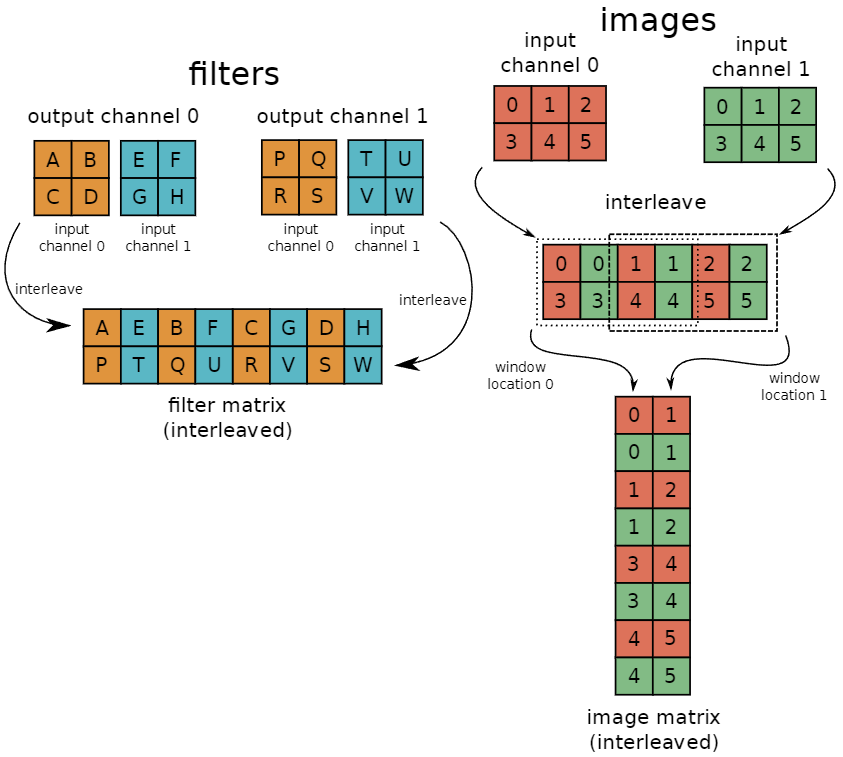

Analyse the graph generated below, notice that every `Conv` node was converted into `Im2Col` and `MatMul` nodes.
The `Im2Col` node represents hardware operation of generating image context for every convolutional window location on the input tensor.

In [ ]:
from qonnx.transformation.lower_convs_to_matmul import LowerConvsToMatMul
from finn.transformation.streamline.absorb import (
    AbsorbTransposeIntoMultiThreshold,
    AbsorbConsecutiveTransposes
)
from finn.transformation.streamline.reorder import (
    MakeMaxPoolNHWC,
)
from finn.transformation.move_reshape import RemoveCNVtoFCFlatten


lowering_transformations = [
    LowerConvsToMatMul(),
    AbsorbTransposeIntoMultiThreshold(),
    MakeMaxPoolNHWC(),
    AbsorbConsecutiveTransposes(),
]

model = ModelWrapper("qalexnet_streamlined.onnx")
for t in lowering_transformations:
    model = model.transform(t)
model.save("qalexnet_lowered.onnx")
#showInNetron("qalexnet_lowered.onnx")

## 6. Conversion to hardware

Now we can convert every node into a dedicated FPGA kernel (implemented in RTL or HLS).


In [ ]:
import finn.transformation.fpgadataflow.convert_to_hw_layers as to_hw
from finn.transformation.move_reshape import RemoveCNVtoFCFlatten


to_hw_transformations = [
    to_hw.InferThresholdingLayer(),
    to_hw.InferQuantizedMatrixVectorActivation(),
    to_hw.InferConvInpGen(),
    to_hw.InferStreamingMaxPool()
]
model = ModelWrapper("qalexnet_lowered.onnx")
model = model.transform(RoundAndClipThresholds())
for t in to_hw_transformations:
    model = model.transform(t)
    
model = model.transform(RemoveCNVtoFCFlatten())
model.save("qalexnet_hardware.onnx")
#showInNetron("qalexnet_hardware.onnx")

In [ ]:
from finn.transformation.fpgadataflow.create_dataflow_partition import (
    CreateDataflowPartition,
)
from qonnx.custom_op.registry import getCustomOp


model = ModelWrapper("qalexnet_hardware.onnx")
parent_model = model.transform(CreateDataflowPartition())
parent_model.save("qalexnet_dataflow_parent.onnx")
sdp_node = parent_model.get_nodes_by_op_type("StreamingDataflowPartition")[0]
sdp_node = getCustomOp(sdp_node)
dataflow_model_filename = sdp_node.get_nodeattr("model")
# save the dataflow partition with a different name for easier access
dataflow_model = ModelWrapper(dataflow_model_filename)
dataflow_model.save("qalexnet_dataflow_model.onnx")

In [ ]:
#showInNetron("qalexnet_dataflow_parent.onnx")

The `StreamingDataflowPartition` node is our network architecture (including preprocessing), which is a graph (shown below), where each node represents a module from finn-hlslib library.
Only that node will be implemented on hardware.


🔔 **TODO (4)** The `Mul` node right after `StreamingDataflowPartition` represents the scaling parameter that is used to compute real number representation of the quantized network output.
Since this operation will not be implemented on the FPGA, we need to save the parameter to use on the CPU part of the board.

- click on the node
- inputs > Mul_0_param0 > "+" sign on the right and copy the parameter value for later

In [ ]:
#showInNetron("qalexnet_dataflow_model.onnx")

## 7. Folding and hardware configuration

Now we have to set the *folding factors* for certain layers to adjust the performance of our accelerator.

In the case of fully connected layers with $IN$ inputs and $OUT$ neurons, the layer operation is given by a matrix multiplication:

$W \cdot x$

Where $W$ is a $[OUT \times IN]$ weight matrix and $x$ is a $[IN \times 1]$ input vector.


As mentioned before, the operation of a regular convolutional layer with a $K \times K$ kernel, $IN_{ch}$ input channels, $OUT_{ch}$ output channels and $N$ output pixels can also be represented by a matrix multiplication:

$F \cdot I$

Where $F$ is a filter matrix of size $[OUT_{ch} \times (IN_{ch} \cdot K^2)]$ and $I$ is an image matrix of size $[(IN_{ch} \cdot K^2) \times N]$.

The MVTU module that computes this matrix-matrix product is composed of Processing Elements (PE), where each PE performs multiplication of Q input lines in parallel:


Now consider an MVTU for a convolutional layer with just one PE with one SIMD line. In such case, all output channels of a single output pixel would be computed in $IN_{ch} \cdot OUT_{ch} \cdot K^2$ cycles. This is the lowest possible level of parallelization and yields the lowest processing speed.
In other extreme case, we could use $OUT_{ch}$ processing elements with $IN_{ch}$ SIMD lines each to compute the output pixel in just $K^2$ cycles. This however may not be possible with big network architectures and FPGAs with low amount of resources.

In order to balance processing speed and resource utilization we can determine $PE$ and $SIMD$ parameters for each layer.
**$IN_{ch}$ has to be divisible by $SIMD$ and $OUT_{ch}$ has to be divisible by $PE$.**
**Also, FINN requires that $SIMD >= IN_{CH} / 1024$.**

In conclusion, the total folding of a convolutional layer (number of cycles to process whole input feature map) is given by:

$TF_{cnv} = H \cdot W \cdot \frac{IN_{ch}}{SIMD} \cdot \frac{OUT_{ch}}{PE} \cdot K^2$

And for fully connected layer:

$TF_{fc} = \frac{IN}{SIMD} \cdot \frac{OUT}{PE}$

**Because FINN is a fine-grained computing architecture, the total processing speed is the processing speed of the slowest layer.**

In order not to waste FPGA resources, total foldings of all layers needs to be as close to each other as possible.

**Notice that total folding of a convolutional layer depends on the input shape, so we need to take maxpooling layers into account when choosing optimal folding parameters**

Because it is not always possible for all layers to have the same total folding, we need to put FIFO buffers between the layers, so the faster layer accelerator won't be stalling the whole processing pipeline while waiting for the following layer to be ready.

🔔 **TODO (5)** Complete the definition of `folding` list that contains folding tuples for each layer. Each layer's folding parameters is defined by a tuple `(PE, SIMD, fifo_depth)`. Remember that `fifo_depth` is a list and a FIFO of depth 128 should be enough for every layer for the input size that we will be using. Maintaining constant total folding won't necessarily be possible for the last fully connected layer, so set it to be the closest value that won't introduce any bottlenecks.

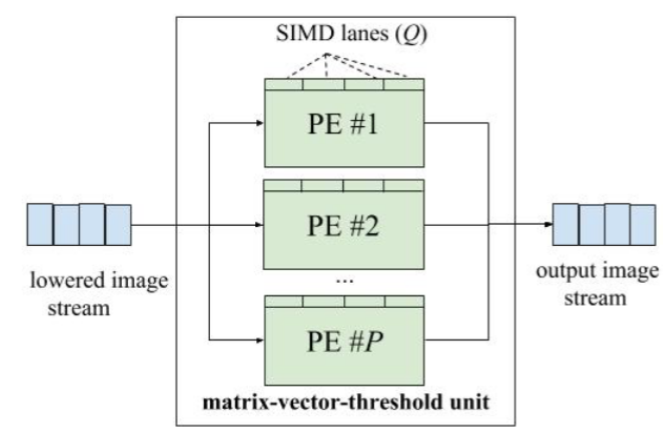

In [ ]:
from qonnx.core.modelwrapper import ModelWrapper
from qonnx.custom_op.registry import getCustomOp
from qonnx.transformation.general import GiveUniqueNodeNames

model = ModelWrapper("qalexnet_specialized.onnx")

# --- TODO 3 START ---
# Lista krotek: (PE, SIMD, in_fifo_depth)
# 1. SIMD w pierwszej warstwie MUSI być równe 3 (kanały RGB).
# 2. PE musi być dzielnikiem liczby filtrów w danej warstwie.
# 3. Dodaj tyle elementów, ile masz warstw MVAU w modelu (AlexNet ma ich zazwyczaj 8).
folding = [
    # (PE, SIMD, FIFO_DEPTH)
    (1, 3, [128]),   # Conv 1: PE=1 (tylko 1 neuron naraz), SIMD=3 (cały wektor RGB naraz)
    (1, 1, [128]),   # Conv 2: Minimalizm - 1 PE, 1 SIMD
    (1, 1, [128]),   # Conv 3: To była Twoja "najcięższa" warstwa - teraz jest najlżejsza
    (1, 1, [128]),   # Conv 4: Redukcja do minimum
    (2, 1, [128])    # FC: 1 PE obsłuży obie klasy (jedną po drugiej)
]
# --- TODO 3 END ---

# 1. Ustawienie MVAU (Obliczenia)
# Uwaga: w nowszych wersjach FINN op_type to "MVAU_rtl"
fc_layers = model.get_nodes_by_op_type("MVAU_rtl")
if not fc_layers: fc_layers = model.get_nodes_by_op_type("MVAU")

for fcl, (pe, simd, ififodepth) in zip(fc_layers, folding):
    fcl_inst = getCustomOp(fcl)
    fcl_inst.set_nodeattr("PE", pe)
    fcl_inst.set_nodeattr("SIMD", simd)
    fcl_inst.set_nodeattr("inFIFODepths", ififodepth)
    fcl_inst.set_nodeattr("ram_style", "distributed")

# 2. Ustawienie ConvolutionInputGenerator (Przesuwne okno)
swg_layers = model.get_nodes_by_op_type("ConvolutionInputGenerator_rtl")
if not swg_layers: swg_layers = model.get_nodes_by_op_type("ConvolutionInputGenerator")

for i in range(len(swg_layers)):
    swg_inst = getCustomOp(swg_layers[i])
    simd = folding[i][1] # Musi być zgodne z MVAU
    swg_inst.set_nodeattr("SIMD", simd)

# 3. DODAJ TO: Obsługa MaxPool (To naprawia błąd z logów)
pool_layers = model.get_nodes_by_op_type("StreamingMaxPool_hls")
for pool in pool_layers:
    pool_inst = getCustomOp(pool)
    pool_inst.set_nodeattr("PE", 1) # Ustawienie PE na 1 jest najbezpieczniejsze

# 4. DODAJ TO: Obsługa Paddingu
pad_layers = model.get_nodes_by_op_type("FMPadding_rtl")
for pad in pad_layers:
    pad_inst = getCustomOp(pad)
    pad_inst.set_nodeattr("SIMD", 1) # Zazwyczaj 1 dla paddingu

model = model.transform(GiveUniqueNodeNames())
model.save("qalexnet_folded.onnx")

In [ ]:
def get_tensor_shape(model, tensor_name):
    # najpierw szukamy w value_info
    for v in model.graph.value_info:
        if v.name == tensor_name:
            return [d.dim_value for d in v.type.tensor_type.shape.dim]
    # jeśli nie ma, szukamy w graph.input
    for v in model.graph.input:
        if v.name == tensor_name:
            return [d.dim_value for d in v.type.tensor_type.shape.dim]
    # jeśli nie ma, szukamy w graph.output
    for v in model.graph.output:
        if v.name == tensor_name:
            return [d.dim_value for d in v.type.tensor_type.shape.dim]
    return None

for i, fcl in enumerate(fc_layers):
    name = fcl.name
    input_name = fcl.input[0]
    output_name = fcl.output[0]
    
    in_shape = get_tensor_shape(model, input_name)
    out_shape = get_tensor_shape(model, output_name)
    
    print(f"Layer {i}: {name}, input shape = {in_shape}, output shape = {out_shape}")


Layer 0: MVAU_rtl_0, input shape = [1, 224, 224, 27], output shape = [1, 224, 224, 32]
Layer 1: MVAU_rtl_1, input shape = [1, 112, 112, 288], output shape = [1, 112, 112, 64]
Layer 2: MVAU_rtl_2, input shape = [1, 56, 56, 576], output shape = [1, 56, 56, 128]
Layer 3: MVAU_rtl_3, input shape = [1, 56, 56, 1152], output shape = [1, 56, 56, 256]
Layer 4: MVAU_rtl_4, input shape = [1, 56, 56, 256], output shape = [1, 2]


## 8. Optimize bitwidths

In [ ]:
from finn.transformation.fpgadataflow.minimize_accumulator_width import MinimizeAccumulatorWidth
from finn.transformation.fpgadataflow.minimize_weight_bit_width import MinimizeWeightBitWidth
from finn.transformation.streamline.round_thresholds import RoundAndClipThresholds


model = ModelWrapper("qalexnet_folded.onnx")
model = model.transform(MinimizeWeightBitWidth())
model = model.transform(MinimizeAccumulatorWidth())
model = model.transform(RoundAndClipThresholds())
model = tidy_up(model)
model.save("qalexnet_optimized.onnx")

Below we visualize in Netron to observe the `StreamingDataWidthConverter` and `StreamingFIFO` nodes that have been inserted into graph, as well as the folding factors in the `PE` and `SIMD` attributes of each `MatrixVectorActivation`.

In [ ]:
#showInNetron("qalexnet_optimized.onnx")

Our network is now ready and we can start with the hardware generation.

## 9. Hardware Generation

We're finally ready to start generating hardware from our network. **This may take over 30 minutes depending on your host computer**.

Using `pynq_part_map` dictionary we can take a look at the available target FPGA boards for our accelerator:

In [ ]:
# print the names of the supported PYNQ boards
from finn.util.basic import pynq_part_map, part_map
from finn.transformation.fpgadataflow.specialize_layers import SpecializeLayers


print(pynq_part_map.keys())
test_pynq_board = "KV260_SOM"
fpga_part = part_map[test_pynq_board]
print("FPGA part:", fpga_part)

model = ModelWrapper("qalexnet_optimized.onnx")
model = model.transform(SpecializeLayers(fpga_part))
model = tidy_up(model)
model.save("qalexnet_specialized.onnx")

dict_keys(['Ultra96', 'Ultra96-V2', 'Pynq-Z1', 'Pynq-Z2', 'ZCU102', 'ZCU104', 'ZCU111', 'RFSoC2x2', 'RFSoC4x2', 'KV260_SOM'])
FPGA part: xck26-sfvc784-2LV-c


In [ ]:
#showInNetron("qalexnet_specialized.onnx")

The `ZynqBuild` function in the cell below will generate HLS code, stitch IPs, create Vivado project with the network and DMA modules for communication with the on-board processing system and generate the final bitstream.

In [ ]:
# model = ModelWrapper("qalexnet_specialized.onnx")

# # Ustawienie głębokości FIFO ręcznie
# for node in model.graph.node:
#     if node.op_type == "StreamingFIFO":
#         node.attr["depth"].i = 8  # np. 8

In [ ]:
# from finn.transformation.fpgadataflow.make_zynq_proj import ZynqBuild

# target_clk_ns = 10
# model = ModelWrapper("qalexnet_specialized.onnx")
# model = model.transform(ZynqBuild(platform = test_pynq_board, period_ns = target_clk_ns))
# model.save("qalexnet_bitstream_complete.onnx")

# print('ZynqBuild done.')

In [ ]:
!cat /tmp/finn_dev_patryk/vivado_zynq_proj_bzmnk45u/vivado.log

cat: /tmp/finn_dev_patryk/vivado_zynq_proj_bzmnk45u/vivado.log: No such file or directory


In [ ]:
!rm -rf /tmp/finn_dev_patryk 

rm: cannot remove '/tmp/finn_dev_patryk': Operation not permitted


In [1]:
import finn.builder.build_dataflow as build
import finn.builder.build_dataflow_config as build_cfg
import os
import shutil

model_file = "qalexnet_specialized.onnx"

estimates_output_dir = "IP_core_SASv2"
#estimates_output_dir = "output_estimates_only"

#Delete previous run results if exist
if os.path.exists(estimates_output_dir):
    shutil.rmtree(estimates_output_dir)
    print("Previous run results deleted!")


cfg_estimates = build.DataflowBuildConfig(
    output_dir          = estimates_output_dir,
    mvau_wwidth_max     = 80,
    target_fps          = 10,   # Obniżamy, żeby FINN nie szalał z zasobami
    synth_clk_period_ns = 10.0, 
    fpga_part           = "xck26-sfvc784-2LV-c",
    
    # WYŁĄCZAMY automatyczne głębokości
    auto_fifo_depths    = False, 
    
    generate_outputs=[
        build_cfg.DataflowOutputType.STITCHED_IP,
        build_cfg.DataflowOutputType.ESTIMATE_REPORTS,
        # build_cfg.DataflowOutputType.BITFILE, # Dodaj to, żeby dostać gotowy plik na FPGA
        # build_cfg.DataflowOutputType.PYNQ_DRIVER # Sterownik do Pythona na Kria
    ]
)

build.build_dataflow_cfg(model_file, cfg_estimates)

Previous run results deleted!
Building dataflow accelerator from qalexnet_specialized.onnx
Intermediate outputs will be generated in /tmp/finn_dev_patryk
Final outputs will be generated in IP_core_SASv2
Build log is at IP_core_SASv2/build_dataflow.log
Running step: step_qonnx_to_finn [1/19]
Running step: step_tidy_up [2/19]
Running step: step_streamline [3/19]
Running step: step_convert_to_hw [4/19]
Running step: step_create_dataflow_partition [5/19]
Running step: step_specialize_layers [6/19]
Running step: step_target_fps_parallelization [7/19]
Running step: step_apply_folding_config [8/19]
Running step: step_minimize_bit_width [9/19]
Running step: step_generate_estimate_reports [10/19]
Running step: step_hw_codegen [11/19]
Running step: step_hw_ipgen [12/19]
Running step: step_set_fifo_depths [13/19]
Running step: step_create_stitched_ip [14/19]
Running step: step_measure_rtlsim_performance [15/19]
Running step: step_out_of_context_synthesis [16/19]
Running step: step_synthesize_bitf

0

In [ ]:
!cat output_estimates_only/report/estimate_layer_resources.json

{
  "FMPadding_rtl_0": {
    "BRAM_18K": 0,
    "BRAM_efficiency": 1,
    "LUT": 0,
    "URAM": 0,
    "URAM_efficiency": 1,
    "DSP": 0
  },
  "ConvolutionInputGenerator_rtl_0": {
    "BRAM_18K": 0,
    "BRAM_efficiency": 1,
    "LUT": 588,
    "URAM": 0,
    "URAM_efficiency": 1,
    "DSP": 0
  },
  "MVAU_rtl_0": {
    "BRAM_18K": 0,
    "BRAM_efficiency": 1,
    "LUT": 0,
    "URAM": 0,
    "URAM_efficiency": 1,
    "DSP": 18
  },
  "Thresholding_rtl_0": {
    "BRAM_18K": 0,
    "BRAM_efficiency": 1,
    "LUT": 2600.0,
    "URAM": 0,
    "URAM_efficiency": 1,
    "DSP": 0
  },
  "StreamingMaxPool_hls_0": {
    "BRAM_18K": 0,
    "BRAM_efficiency": 1,
    "LUT": 0,
    "URAM": 0,
    "URAM_efficiency": 1,
    "DSP": 0
  },
  "FMPadding_rtl_1": {
    "BRAM_18K": 0,
    "BRAM_efficiency": 1,
    "LUT": 0,
    "URAM": 0,
    "URAM_efficiency": 1,
    "DSP": 0
  },
  "ConvolutionInputGenerator_rtl_1": {
    "BRAM_18K": 0,
    "BRAM_efficiency": 1,
    "LUT": 1868,
    "URAM": 0,
    "UR

In [ ]:
!cp /home/patryk/Desktop/MASTER_THIESIS/finn_SAS/finn/notebooks/IP_core/stitched_ip -r /home/patryk/Desktop/MASTER_THIESIS/Ip_core


cp: cannot create directory '/home/patryk/Desktop/MASTER_THIESIS/Ip_core': Permission denied


In [ ]:
!mkdir /home/patryk/Desktop/MASTER_THIESIS/Ip_core

mkdir: cannot create directory ‘/home/patryk/Desktop/MASTER_THIESIS/Ip_core’: Permission denied


In [ ]:
test_pynq_board

'KV260_SOM'

In [ ]:
from finn.transformation.fpgadataflow.create_stitched_ip import CreateStitchedIP

# model to Twój przetransformowany qalexnet
model = model.transform(CreateStitchedIP(test_pynq_board, target_clk_ns))
model.save("qalexnet_stitched_ip.onnx")

In [ ]:
for i, fcl in enumerate(fc_layers):
    print(f"Layer {i}: {fcl.name}, M (OUT) = {fcl.get_nodeattr('M')}, N (IN) = {fcl.get_nodeattr('N')}")


## 10. Deployment

After the `ZynqBuild` we run one additional transformation to generate a PYNQ driver for the accelerator.

In [ ]:
from finn.transformation.fpgadataflow.make_pynq_driver import MakePYNQDriver

model = ModelWrapper("qalexnet_bitstream_complete.onnx")
model = model.transform(MakePYNQDriver("zynq-iodma"))

The bitfile and generated driver files(s) will be copied into a deployment folder which then can be used to run the network on the PYNQ board:

In [ ]:
from shutil import copy
from distutils.dir_util import copy_tree
from finn.util.basic import make_build_dir


# create directory for deployment files
deployment_dir = make_build_dir(prefix="pynq_deployment_")
model.set_metadata_prop("pynq_deployment_dir", deployment_dir)

# get and copy necessary files
# .bit and .hwh file
bitfile = model.get_metadata_prop("bitfile")
hwh_file = model.get_metadata_prop("hw_handoff")
deploy_files = [bitfile, hwh_file]

for dfile in deploy_files:
    if dfile is not None:
        copy(dfile, deployment_dir)

# driver.py and python libraries
pynq_driver_dir = model.get_metadata_prop("pynq_driver_dir")
copy_tree(pynq_driver_dir, deployment_dir)

FINN puts all of the output (network modules from Vivado HLS, intermediate vivado projects, the final deployment, etc.) in the `\tmp\finn_dev_<username>` directory.

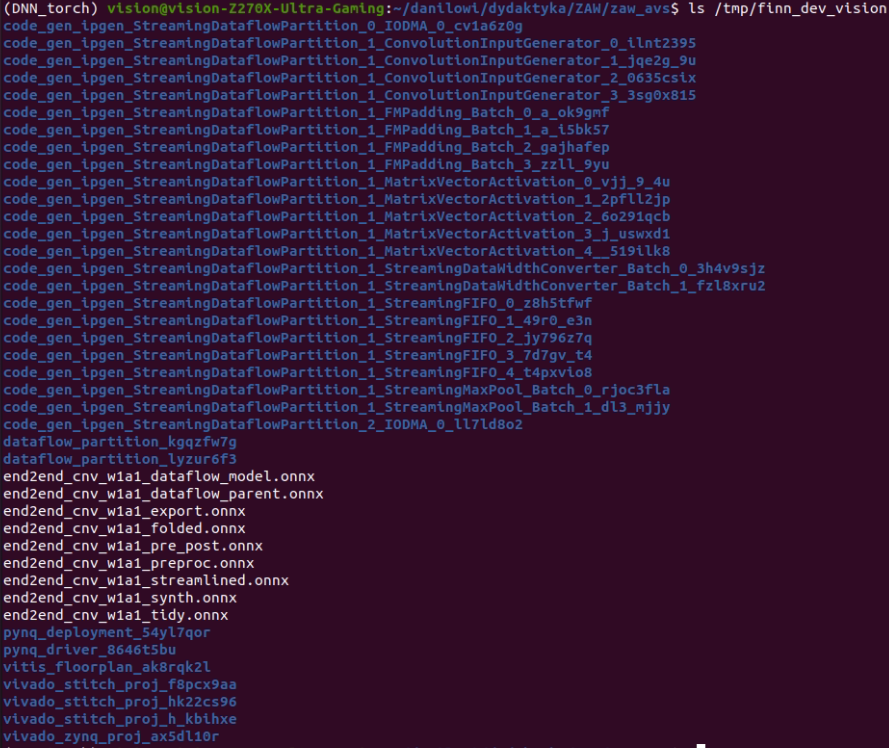

For now, the two most important outputs are `pynq_deployment_<hash>` and `vivado_zynq_project_<hash>`.
The `vivado_zynq_project_<hash>` is a vivado project generated by FINN which contains the top level block design with our network accelerator and DMAs for communication between the programmable logic and the processing system.
The `pynq_deployment_<hash>` directory contains a processing system driver (`driver.py`) for writing and reading data from the block design defined in `vivado_zynq_project_<hash>`. The deployment also contains the bitstream  (`resizer.bit`) and the hardware handoff file (`resizer.hwh`) of the block design.

🔔**TODO (6)**
- Put `test_mnist.npy` (from previous exercise) test input into the deployment directory.
- Connect the Kria board with an ethernet cable into network common with your host PC
- Using SSH, copy the deployment directory to the board.
- Access the board's shell, go into the deployment directory and setup the PYNQ environment:

`sudo su`

`source /etc/profile.d/pynq_venv.sh`
- You may need to install additional python modules:

`pip install bitstring`
- run the accelerator on the test input:

`python driver.py --inputfile test_mnist.npy`
- Analyse the result `output.npy` file
- Don't forget to multiply the result by the `Mul` value from the `qalexnet_dataflow_parent.onnx` graph - use Python on the board.